# Apriori Algorithm Experiment

Notebook ini digunakan untuk membangun model Association Rule Mining menggunakan algoritma Apriori.

In [1]:
import pandas as pd

from mlxtend.preprocessing import (
    TransactionEncoder
)

from mlxtend.frequent_patterns import (
    apriori,
    association_rules
)

In [2]:
df = pd.read_csv(
    "../dataset/GroceryStoreDataset.csv"
    )
df.head()

,TransactionID,Items
0,1,"TELUR,SAUS,MIE INSTAN"
1,2,"SUSU,KEJU,ROTI,KRIMER"
2,3,"BISKUIT,GULA,COKLAT,AIR MINERAL,TEH"
3,4,"PASTA GIGI,SAUS,SHAMPOO,SABUN"
4,5,"PASTA GIGI,SHAMPOO,SABUN,BERAS,MIE INSTAN,KRIMER"


In [4]:
transactions = df["Items"].apply(
    lambda x: [item.strip() for item in x.split(",")]
).tolist()

te = TransactionEncoder()

te_array = (
    te.fit(transactions)
      .transform(transactions)
)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

basket.head()

,AIR MINERAL,BERAS,BISKUIT,COKLAT,GULA,KEJU,KOPI,KRIMER,MIE INSTAN,MINYAK,...,ROTI,SABUN,SAUS,SELai,SEREAL,SHAMPOO,SNACK,SUSU,TEH,TELUR
0,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
1,False,False,False,False,False,True,False,True,False,False,...,True,False,False,False,False,False,False,True,False,False
2,True,False,True,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,True,False,False,True,False,False,False,False
4,False,True,False,False,False,False,False,True,True,False,...,False,True,False,False,False,True,False,False,False,False


In [5]:
frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.2230,frozenset({AIR MINERAL})
1,0.1935,frozenset({BERAS})
2,0.3175,frozenset({BISKUIT})
3,0.2055,frozenset({COKLAT})
4,0.2315,frozenset({GULA})


In [6]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.2
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({BISKUIT}),frozenset({AIR MINERAL}),0.3175,0.2230,0.1130,0.355906,1.595989,1.0,0.042197,1.206345,0.547149,0.264327,0.171050,0.431316
1,frozenset({AIR MINERAL}),frozenset({BISKUIT}),0.2230,0.3175,0.1130,0.506726,1.595989,1.0,0.042197,1.383614,0.480604,0.264327,0.277255,0.431316
2,frozenset({MINYAK}),frozenset({AIR MINERAL}),0.1790,0.2230,0.0375,0.209497,0.939449,1.0,-0.002417,0.982919,-0.072791,0.102881,-0.017378,0.188829
3,frozenset({AIR MINERAL}),frozenset({ROTI}),0.2230,0.3275,0.0560,0.251121,0.766782,1.0,-0.017032,0.898009,-0.281322,0.113246,-0.113575,0.211057
4,frozenset({SNACK}),frozenset({AIR MINERAL}),0.2030,0.2230,0.1005,0.495074,2.220062,1.0,0.055231,1.538839,0.689539,0.308756,0.350159,0.472873


In [7]:
rules.sort_values(
    by='confidence',
    ascending=False
).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
974,"frozenset({SHAMPOO, PASTA GIGI, COKLAT})",frozenset({SABUN}),0.0125,0.2425,0.0120,0.960000,3.958763,1.0,0.008969,18.937500,0.756857,0.049383,0.947195,0.504742
1119,"frozenset({ROTI, SHAMPOO, SEREAL})",frozenset({SUSU}),0.0130,0.3995,0.0120,0.923077,2.310581,1.0,0.006807,7.806500,0.574679,0.029963,0.871902,0.476557
950,"frozenset({ROTI, SELai, BERAS})",frozenset({SUSU}),0.0115,0.3995,0.0105,0.913043,2.285466,1.0,0.005906,6.905750,0.568996,0.026217,0.855193,0.469663
990,"frozenset({SUSU, SELai, GULA})",frozenset({ROTI}),0.0110,0.3275,0.0100,0.909091,2.775850,1.0,0.006398,7.397500,0.646866,0.030441,0.864819,0.469813
1045,"frozenset({SAUS, TELUR, SELai})",frozenset({MIE INSTAN}),0.0110,0.2240,0.0100,0.909091,4.058442,1.0,0.007536,8.536000,0.761982,0.044444,0.882849,0.476867
1099,"frozenset({SUSU, SELai, SEREAL})",frozenset({ROTI}),0.0215,0.3275,0.0195,0.906977,2.769395,1.0,0.012459,7.229375,0.652949,0.059181,0.861675,0.483259
1098,"frozenset({ROTI, SELai, SEREAL})",frozenset({SUSU}),0.0215,0.3995,0.0195,0.906977,2.270280,1.0,0.010911,6.455375,0.571820,0.048568,0.845090,0.477894
1000,"frozenset({SABUN, SUSU, KEJU})",frozenset({ROTI}),0.0150,0.3275,0.0135,0.900000,2.748092,1.0,0.008587,6.725000,0.645798,0.041033,0.851301,0.470611
1013,"frozenset({ROTI, KEJU, SEREAL})",frozenset({SUSU}),0.0195,0.3995,0.0175,0.897436,2.246398,1.0,0.009710,5.854875,0.565877,0.043587,0.829202,0.470620
938,"frozenset({MINYAK, GULA, BERAS})",frozenset({TELUR}),0.0135,0.2540,0.0120,0.888889,3.499563,1.0,0.008571,6.714000,0.724024,0.046967,0.851057,0.468066


In [9]:
import matplotlib.pyplot as plt

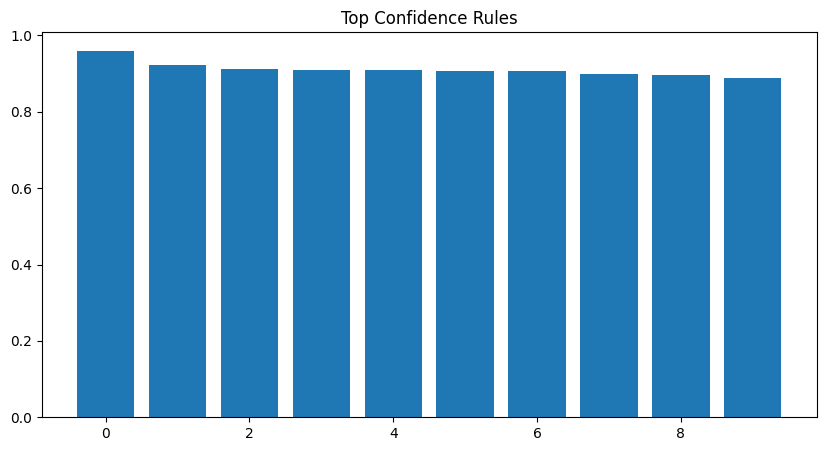

In [10]:
top_rules = rules.nlargest(
    10,
    'confidence'
)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top_rules)),
    top_rules['confidence']
)

plt.title(
    "Top Confidence Rules"
)

plt.show()